# Loading And Graphing Monthly Summaries

In [52]:
# Make the json_helper module available to this notebook.
import sys
import importlib

# Force clear cached modules
if 'json_helper' in sys.modules:
    del sys.modules['json_helper']
if 'tokengrabber' in sys.modules:
    del sys.modules['tokengrabber']

import os
os.environ['NOAA_TOKEN'] = 'GQSNnsbUslNHBAPVDfWdwswxGsQNiutO'

from json_helper import fetch_and_load_chunked_dataframe

In [53]:
# Using the json_helper module, load all of the json files acquired in part one of this lab into a Pandas DataFrame.

from json_helper import fetch_and_load_chunked_dataframe

df = fetch_and_load_chunked_dataframe(
    start_year=1938,
    end_year=2026,
    datasetid="GSOM",
)

df.head()

✓ Page 0: offset 1, got 154 records (page), 154 total → monthly_summaries_FIPS10003_19380101_19421231_0.json
✓ Reached end of data at page 0
Found 1 JSON files
Loaded 154 records into DataFrame
✓ Page 0: offset 1, got 179 records (page), 179 total → monthly_summaries_FIPS10003_19430101_19471231_0.json
✓ Reached end of data at page 0
Found 2 JSON files
Loaded 333 records into DataFrame
✓ Page 0: offset 1, got 250 records (page), 250 total → monthly_summaries_FIPS10003_19480101_19521231_0.json
✓ Reached end of data at page 0
Found 3 JSON files
Loaded 583 records into DataFrame
✓ Page 0: offset 1, got 247 records (page), 247 total → monthly_summaries_FIPS10003_19530101_19571231_0.json
✓ Reached end of data at page 0
Found 4 JSON files
Loaded 830 records into DataFrame
✓ Page 0: offset 1, got 230 records (page), 230 total → monthly_summaries_FIPS10003_19580101_19621231_0.json
✓ Reached end of data at page 0
Found 5 JSON files
Loaded 1060 records into DataFrame
NOAA API request failed (HTTP

,date,datatype,station,attributes,value
0,1938-01-01T00:00:00,TAVG,GHCND:USC00072625,",6",1.34
1,1938-01-01T00:00:00,TAVG,GHCND:USC00079605,"1,6",0.43
2,1938-02-01T00:00:00,TAVG,GHCND:USC00072625,",6",3.80
3,1938-02-01T00:00:00,TAVG,GHCND:USC00079605,",6",2.47
4,1938-03-01T00:00:00,TAVG,GHCND:USC00072625,",6",7.83


In [56]:
# Display a summary of the DataFrame
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 35676 entries, 0 to 35675
Data columns (total 5 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   date        35676 non-null  str    
 1   datatype    35676 non-null  str    
 2   station     35676 non-null  str    
 3   attributes  35676 non-null  str    
 4   value       35676 non-null  float64
dtypes: float64(1), str(4)
memory usage: 1.4 MB


In [58]:
# How many stations are there?
# How many rows are associated with each DataFrame?
df.groupby("station").size()

station
GHCND:USC00071200      517
GHCND:USC00072625     2910
GHCND:USC00075852     4533
GHCND:USC00076405       85
GHCND:USC00076410     8701
GHCND:USC00078510      512
GHCND:USC00079605    10137
GHCND:USW00013781     8281
dtype: int64

# Narrow our analysis to station id: GHCND:USW00013781

https://www.ncdc.noaa.gov/cdo-web/api/v2/stations/GHCND:USC00071200

```json
{
    "elevation": 24.1,
    "mindate": "1948-01-01",
    "maxdate": "2019-12-05",
    "latitude": 39.6744,
    "name": "WILMINGTON NEW CASTLE CO AIRPORT, DE US",
    "datacoverage": 1,
    "id": "GHCND:USW00013781",
    "elevationUnit": "METERS",
    "longitude": -75.60567
}
```

In [60]:
# Create a DataFrame called "df_wilm_readings". 
# This DataFrame should only contain records associated with station id 'GHCND:USW00013781'.

df_wilm_readings = df[df['station'] == 'GHCND:USW00013781']
df_wilm_readings

,date,datatype,station,attributes,value
127,1942-05-01T00:00:00,TAVG,GHCND:USW00013781,",Z",19.25
131,1942-06-01T00:00:00,TAVG,GHCND:USW00013781,",Z",22.40
135,1942-07-01T00:00:00,TAVG,GHCND:USW00013781,",Z",24.67
139,1942-08-01T00:00:00,TAVG,GHCND:USW00013781,"1,Z",22.70
143,1942-09-01T00:00:00,TAVG,GHCND:USW00013781,",Z",20.09
...,...,...,...,...,...
35664,2002-08-01T00:00:00,TAVG,GHCND:USW00013781,",0",25.43
35667,2002-09-01T00:00:00,TAVG,GHCND:USW00013781,",0",20.73
35669,2002-10-01T00:00:00,TAVG,GHCND:USW00013781,",0",13.02
35672,2002-11-01T00:00:00,TAVG,GHCND:USW00013781,",0",6.43


In [61]:
# Display a summary of the df_wilm_readings DataFrame.
df_wilm_readings.info()

<class 'pandas.DataFrame'>
Index: 8281 entries, 127 to 35675
Data columns (total 5 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   date        8281 non-null   str    
 1   datatype    8281 non-null   str    
 2   station     8281 non-null   str    
 3   attributes  8281 non-null   str    
 4   value       8281 non-null   float64
dtypes: float64(1), str(4)
memory usage: 388.2 KB


In [62]:
# Create a DataFrame called jan_readings.
# This DataFrame should filter the contents of df_wilm_readings in such a way that it only keeps records 
# which are associated with the month of January.
# Make sure that rows are sorted by date.
import pandas as pd

jan_readings = df_wilm_readings.copy()
jan_readings['date'] = pd.to_datetime(jan_readings['date'])
jan_readings = jan_readings[jan_readings['date'].dt.month == 1].sort_values('date')
jan_readings

,date,datatype,station,attributes,value
823,1948-01-01,TAVG,GHCND:USW00013781,",X",-3.67
9261,1948-01-01,TAVG,GHCND:USW00013781,",X",-3.67
25124,1948-01-01,TAVG,GHCND:USW00013781,",X",-3.67
5511,1948-01-01,TAVG,GHCND:USW00013781,",X",-3.67
35261,1948-01-01,TAVG,GHCND:USW00013781,",X",-3.67
...,...,...,...,...,...
29254,2022-01-01,TAVG,GHCND:USW00013781,",W",-0.53
32527,2023-01-01,TAVG,GHCND:USW00013781,",W",5.97
32563,2024-01-01,TAVG,GHCND:USW00013781,",W",1.82
32599,2025-01-01,TAVG,GHCND:USW00013781,",W",-1.15


In [63]:
# What is the shape of jan_readings?
jan_readings.shape

(679, 5)

* Create a line graph which meets the following requirements:
* The x axis should represent the year.
* The y axis should represent the temperature in celsius.
* Each point should display the average temperature in celsius for a given year.
* At a minimum it should display data from 1938 to 2017. 
* Make sure to include the x and y labels. 
* Make sure that x and y ticks are readable. 

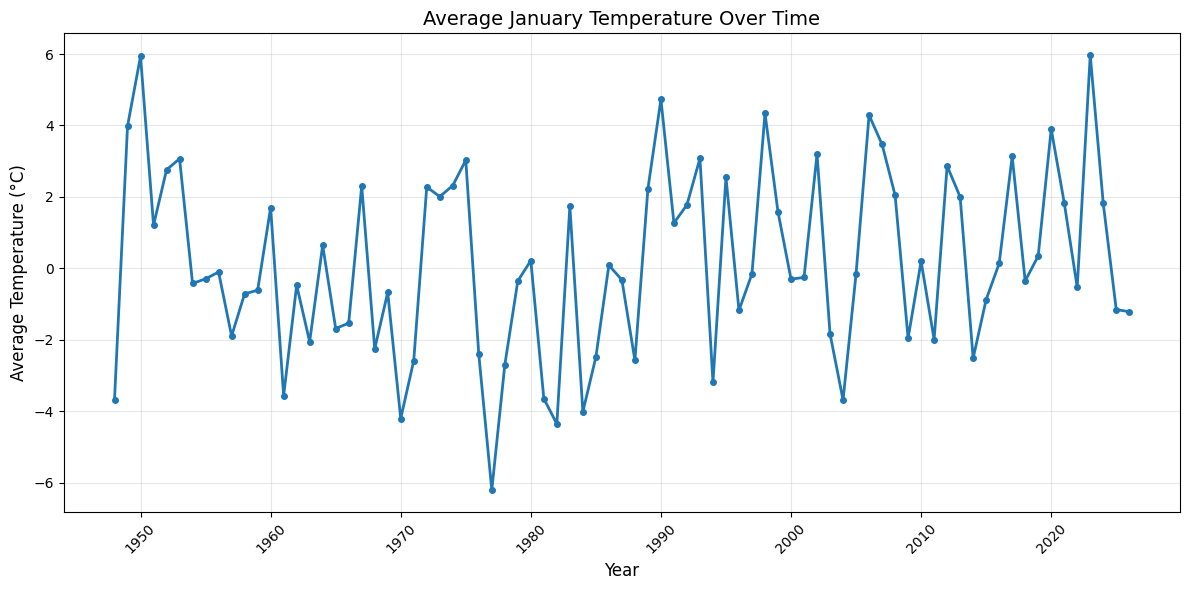

In [64]:
import matplotlib.pyplot as plt

# Extract year and calculate average temperature per year
jan_readings_copy = jan_readings.copy()
jan_readings_copy['year'] = jan_readings_copy['date'].dt.year
yearly_avg = jan_readings_copy.groupby('year')['value'].mean()

# Create line graph
plt.figure(figsize=(12, 6))
plt.plot(yearly_avg.index, yearly_avg.values, marker='o', linewidth=2, markersize=4)
plt.xlabel('Year', fontsize=12)
plt.ylabel('Average Temperature (°C)', fontsize=12)
plt.title('Average January Temperature Over Time', fontsize=14)
plt.grid(True, alpha=0.3)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()